<center><h1>Kotamraju_KrishnaKarthik_HW2</h1></center>
<br>
<br>

Name: Krishna Karthik Kotamraju
<br>
Github Username: karthik05k9
<br>
USC ID: 9984105385

## 1. Combined Cycle Power Plant Data Set

### (a) Download Data

Package imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm

from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsRegressor
from sklearn.preprocessing import PolynomialFeatures, StandardScaler


Get the Cycle Power Plant Data Set

In [2]:
data = pd.read_excel("Homework 2 Data/CCPP/Folds5x2_pp.xlsx", sheet_name="Sheet1")
data.head()

,AT,V,AP,RH,PE
0,14.96,41.76,1024.07,73.17,463.26
1,25.18,62.96,1020.04,59.08,444.37
2,5.11,39.40,1012.16,92.14,488.56
3,20.86,57.32,1010.24,76.64,446.48
4,10.82,37.50,1009.23,96.62,473.90


### (b) Exploring the data

#### i. Rows and columns

In [3]:
print("Rows:", data.shape[0])
print("Columns:", data.shape[1])

Rows: 9568
Columns: 5


Each row is one hourly observation from the power plant. The columns AT, V, AP, and RH are the predictors. PE is the electrical energy output that we want to predict.

#### ii. Pairwise scatterplots of all the variables

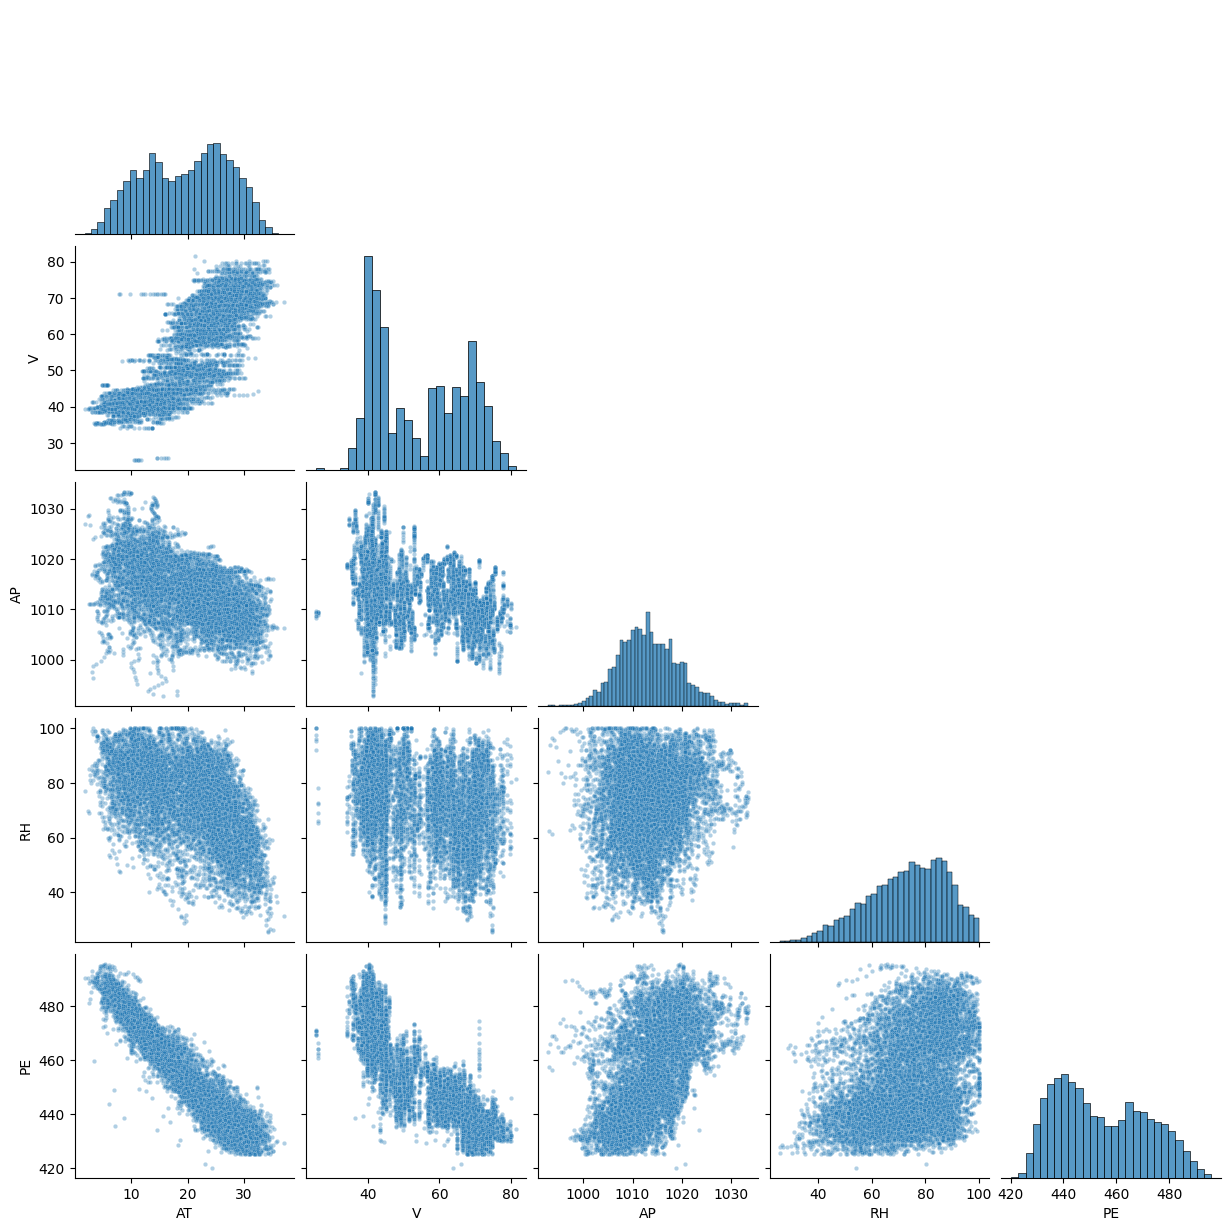

In [4]:
sns.pairplot(data, corner=True, plot_kws={"s": 10, "alpha": 0.35})
plt.show()

PE has a strong negative relationship with AT and V. AP has a weaker positive relationship with PE, while RH has a weaker relationship. Some predictor pairs are also related, so their coefficients may change in the multiple regression model.

#### iii. Summary statistics

In [5]:
summary = pd.DataFrame({
    "mean": data.mean(),
    "median": data.median(),
    "range": data.max() - data.min(),
    "Q1": data.quantile(0.25),
    "Q3": data.quantile(0.75)
})
summary["IQR"] = summary["Q3"] - summary["Q1"]
summary.round(3)

,mean,median,range,Q1,Q3,IQR
AT,19.651,20.345,35.30,13.510,25.72,12.210
V,54.306,52.080,56.20,41.740,66.54,24.800
AP,1013.259,1012.940,40.41,1009.100,1017.26,8.160
RH,73.309,74.975,74.60,63.328,84.83,21.502
PE,454.365,451.550,75.50,439.750,468.43,28.680


### (c) Simple Linear Regression

In [6]:
def fit_ols(X, y):
    X_with_constant = sm.add_constant(X, has_constant="add")
    return sm.OLS(y, X_with_constant).fit()


def predict_ols(model, X):
    X_with_constant = sm.add_constant(X, has_constant="add")
    return model.predict(X_with_constant)


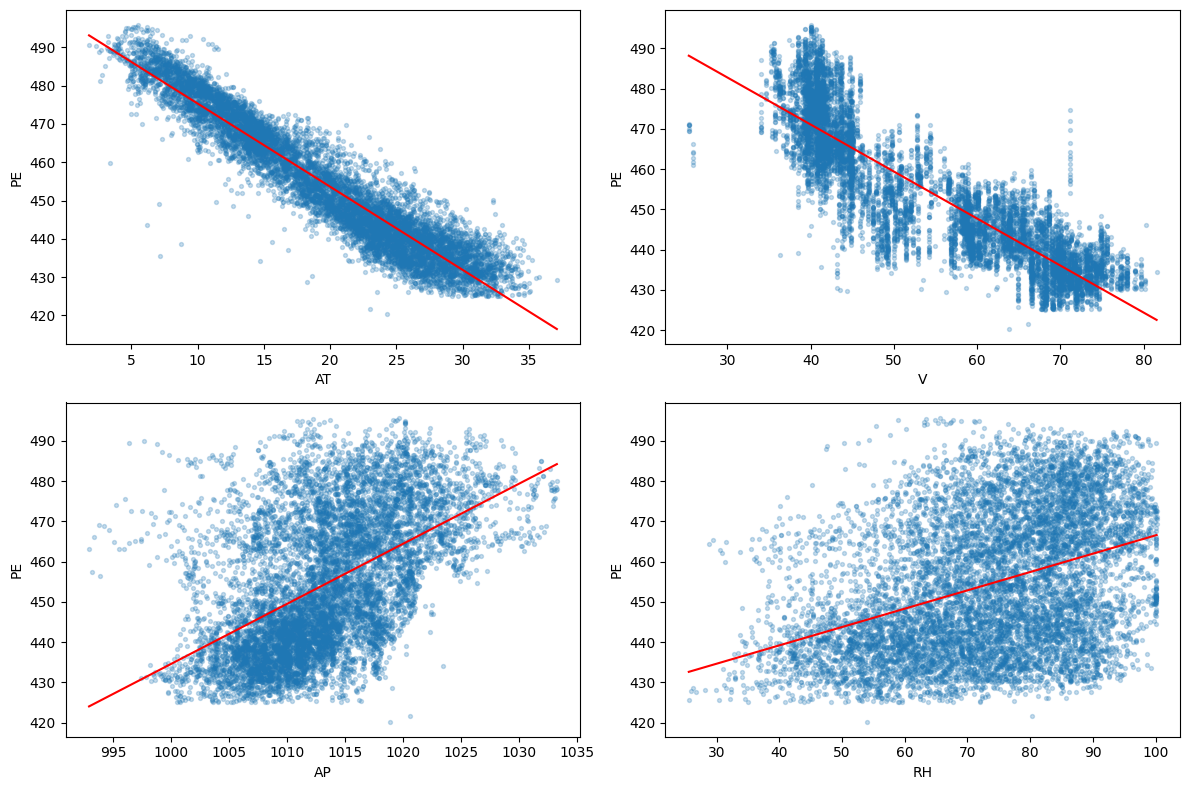

,predictor,coefficient,p_value,R_squared,possible_outliers
0,AT,-2.17132,0.0,0.89895,42
1,V,-1.16814,0.0,0.75652,33
2,AP,1.48987,0.0,0.26877,28
3,RH,0.45565,0.0,0.15194,2


In [7]:
predictors = ["AT", "V", "AP", "RH"]
y = data["PE"]
simple_rows = []
simple_coefficients = {}

fig, axes = plt.subplots(2, 2, figsize=(12, 8))

for predictor, axis in zip(predictors, axes.flat):
    model = fit_ols(data[[predictor]], y)
    prediction = model.predict()
    standardized_residuals = (model.resid - model.resid.mean()) / model.resid.std()
    possible_outliers = np.sum(np.abs(standardized_residuals) > 3)

    simple_coefficients[predictor] = model.params[predictor]
    simple_rows.append([
        predictor,
        model.params[predictor],
        model.pvalues[predictor],
        model.rsquared,
        possible_outliers
    ])

    order = np.argsort(data[predictor].to_numpy())
    axis.scatter(data[predictor], y, s=8, alpha=0.25)
    axis.plot(data[predictor].to_numpy()[order], prediction[order], color="red")
    axis.set_xlabel(predictor)
    axis.set_ylabel("PE")

plt.tight_layout()
plt.show()

simple_results = pd.DataFrame(
    simple_rows,
    columns=["predictor", "coefficient", "p_value", "R_squared", "possible_outliers"]
)
simple_results.round(5)


All four predictors have p-values below 0.05, so each has a statistically significant association with PE when considered alone. AT has the largest R-squared. Points with standardized residual magnitude above 3 are noted as possible outliers. I do not remove them because they are plausible observations and there is no evidence that they are data-entry errors.

### (d) Multiple Regression

In [8]:
multiple_model = fit_ols(data[predictors], y)
multiple_results = pd.DataFrame({
    "coefficient": multiple_model.params,
    "p_value": multiple_model.pvalues
})

print("R-squared:", round(multiple_model.rsquared, 4))
multiple_results.round(6)


R-squared: 0.9287


,coefficient,p_value
const,454.609274,0.0
AT,-1.977513,0.0
V,-0.233916,0.0
AP,0.062083,0.0
RH,-0.158054,0.0


At the 0.05 level, AT, V, AP, and RH are all statistically significant because all four p-values are below 0.05. The multiple model has R-squared 0.9287, which is higher than every simple regression model.

### (e) Compare Simple and Multiple Regression

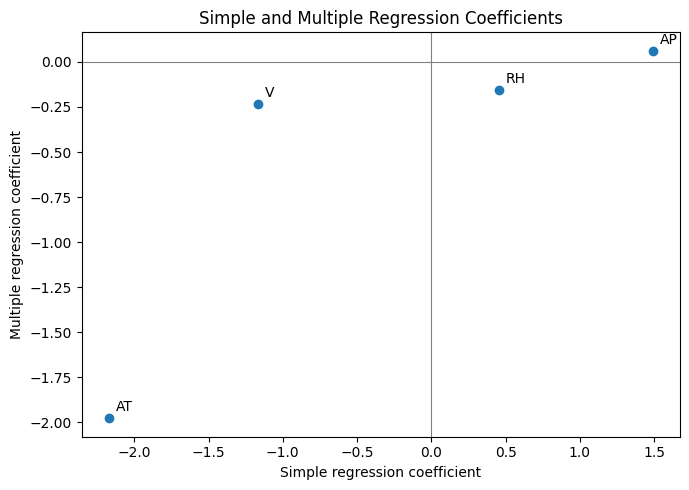

In [9]:
simple_values = [simple_coefficients[name] for name in predictors]
multiple_values = [multiple_model.params[name] for name in predictors]

plt.figure(figsize=(7, 5))
plt.scatter(simple_values, multiple_values)

for name, x_value, y_value in zip(predictors, simple_values, multiple_values):
    plt.annotate(name, (x_value, y_value), xytext=(5, 5), textcoords="offset points")

plt.axhline(0, color="gray", linewidth=0.8)
plt.axvline(0, color="gray", linewidth=0.8)
plt.xlabel("Simple regression coefficient")
plt.ylabel("Multiple regression coefficient")
plt.title("Simple and Multiple Regression Coefficients")
plt.tight_layout()
plt.show()


The coefficients change after the other predictors are included. This happens because the predictors contain overlapping information. RH changes sign between the simple and multiple models.

### (f) Nonlinear Association

In [10]:
nonlinear_rows = []

for predictor in predictors:
    x = (data[predictor] - data[predictor].mean()) / data[predictor].std()
    X_poly = pd.DataFrame({
        predictor: x,
        predictor + "^2": x ** 2,
        predictor + "^3": x ** 3
    })
    model = fit_ols(X_poly, y)
    nonlinear_rows.append([
        predictor,
        model.pvalues[predictor + "^2"],
        model.pvalues[predictor + "^3"],
        model.rsquared
    ])

nonlinear_results = pd.DataFrame(
    nonlinear_rows,
    columns=["predictor", "quadratic_p", "cubic_p", "R_squared"]
)
nonlinear_results.round(6)


,predictor,quadratic_p,cubic_p,R_squared
0,AT,0.000000,0.000000,0.911883
1,V,0.000000,0.013735,0.775022
2,AP,0.000000,0.000000,0.297543
3,RH,0.101395,0.000014,0.153743


Every predictor shows evidence of a nonlinear association with PE. AT and AP have significant quadratic and cubic terms. For V, both the quadratic and cubic terms are significant. For RH, the quadratic term is not significant, but the cubic term is significant at the 0.05 level.

### (g) Interactions of Predictors

In [11]:
interaction_builder = PolynomialFeatures(
    degree=2, interaction_only=True, include_bias=False
)
X_interactions = interaction_builder.fit_transform(data[predictors])
interaction_names = interaction_builder.get_feature_names_out(predictors)
X_interactions = pd.DataFrame(X_interactions, columns=interaction_names)

interaction_model = fit_ols(X_interactions, y)
interaction_only = [name for name in interaction_names if " " in name]

print("R-squared:", round(interaction_model.rsquared, 4))
pd.DataFrame({
    "coefficient": interaction_model.params[interaction_only],
    "p_value": interaction_model.pvalues[interaction_only]
}).round(6)


R-squared: 0.9363


,coefficient,p_value
AT V,0.020971,0.000000
AT AP,0.001759,0.452051
AT RH,-0.005230,0.000000
V AP,0.006812,0.000000
V RH,0.000839,0.086194
AP RH,-0.001612,0.033606


The significant interaction terms are AT V, AT RH, V AP, and AP RH. AT AP and V RH are not significant at the 0.05 level.

### (h) Improvement

In [12]:
train_data, test_data = train_test_split(
    data, test_size=0.30, random_state=42
)

linear_model = fit_ols(train_data[predictors], train_data["PE"])
linear_train_prediction = predict_ols(linear_model, train_data[predictors])
linear_test_prediction = predict_ols(linear_model, test_data[predictors])

linear_train_mse = mean_squared_error(train_data["PE"], linear_train_prediction)
linear_test_mse = mean_squared_error(test_data["PE"], linear_test_prediction)

print("Training rows:", len(train_data))
print("Test rows:", len(test_data))
print("Linear train MSE:", round(linear_train_mse, 3))
print("Linear test MSE:", round(linear_test_mse, 3))


Training rows: 6697
Test rows: 2871
Linear train MSE: 20.581
Linear test MSE: 21.24


In [13]:
quadratic_builder = PolynomialFeatures(degree=2, include_bias=False)
X_train_full = quadratic_builder.fit_transform(train_data[predictors])
X_test_full = quadratic_builder.transform(test_data[predictors])
quadratic_names = quadratic_builder.get_feature_names_out(predictors)

X_train_full = pd.DataFrame(X_train_full, columns=quadratic_names)
X_test_full = pd.DataFrame(X_test_full, columns=quadratic_names)

full_model = fit_ols(X_train_full, train_data["PE"].reset_index(drop=True))
full_train_prediction = predict_ols(full_model, X_train_full)
full_test_prediction = predict_ols(full_model, X_test_full)

full_train_mse = mean_squared_error(train_data["PE"], full_train_prediction)
full_test_mse = mean_squared_error(test_data["PE"], full_test_prediction)

pd.DataFrame({
    "coefficient": full_model.params,
    "p_value": full_model.pvalues
}).round(6)


,coefficient,p_value
const,-7664.980854,0.000000
AT,-7.288543,0.044606
V,-1.958957,0.267182
AP,15.930817,0.000000
RH,3.912130,0.000143
AT^2,0.018495,0.000001
AT V,0.009465,0.003195
AT AP,0.004555,0.196631
AT RH,-0.005260,0.003056
V^2,-0.000365,0.699802


In [14]:
kept_names = []

for name in quadratic_names:
    if name in predictors or full_model.pvalues[name] < 0.05:
        kept_names.append(name)

reduced_model = fit_ols(
    X_train_full[kept_names],
    train_data["PE"].reset_index(drop=True)
)
reduced_train_prediction = predict_ols(reduced_model, X_train_full[kept_names])
reduced_test_prediction = predict_ols(reduced_model, X_test_full[kept_names])

reduced_train_mse = mean_squared_error(train_data["PE"], reduced_train_prediction)
reduced_test_mse = mean_squared_error(test_data["PE"], reduced_test_prediction)

regression_comparison = pd.DataFrame([
    ["Linear", linear_train_mse, linear_test_mse],
    ["All interactions and quadratics", full_train_mse, full_test_mse],
    ["Reduced model", reduced_train_mse, reduced_test_mse]
], columns=["model", "train_MSE", "test_MSE"])

print("Terms kept in the reduced model:", kept_names)
regression_comparison.round(3)


Terms kept in the reduced model: ['AT', 'V', 'AP', 'RH', 'AT^2', 'AT V', 'AT RH', 'AP^2', 'AP RH', 'RH^2']


,model,train_MSE,test_MSE
0,Linear,20.581,21.240
1,All interactions and quadratics,17.888,18.647
2,Reduced model,17.918,18.694


All four main effects are kept to respect the hierarchy rule. The insignificant second-order terms are removed. The full second-order model has the smallest regression test MSE, while the reduced model is slightly simpler with similar error.

### (i) KNN Regression

In [15]:
def knn_errors(X_train, X_test, y_train, y_test):
    rows = []

    for k in range(1, 101):
        model = KNeighborsRegressor(n_neighbors=k)
        model.fit(X_train, y_train)
        train_prediction = model.predict(X_train)
        test_prediction = model.predict(X_test)
        rows.append([
            k,
            mean_squared_error(y_train, train_prediction),
            mean_squared_error(y_test, test_prediction)
        ])

    return pd.DataFrame(rows, columns=["k", "train_MSE", "test_MSE"])


X_train = train_data[predictors]
X_test = test_data[predictors]
y_train = train_data["PE"]
y_test = test_data["PE"]

raw_knn = knn_errors(X_train, X_test, y_train, y_test)
best_raw = raw_knn.loc[raw_knn["test_MSE"].idxmin()]

print("Best raw k:", int(best_raw["k"]))
print("Best raw test MSE:", round(best_raw["test_MSE"], 3))

Best raw k: 5
Best raw test MSE: 15.727


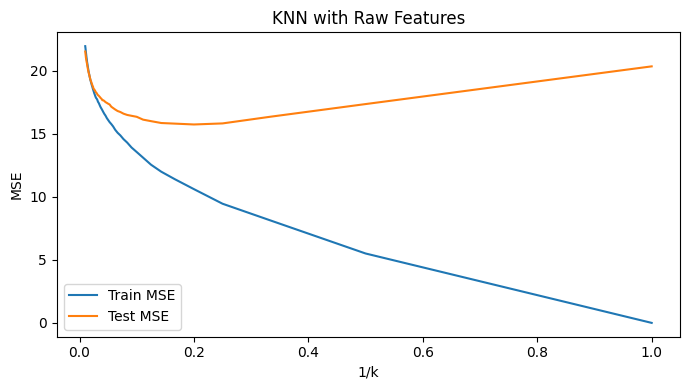

In [16]:
plt.figure(figsize=(7, 4))
plt.plot(1 / raw_knn["k"], raw_knn["train_MSE"], label="Train MSE")
plt.plot(1 / raw_knn["k"], raw_knn["test_MSE"], label="Test MSE")
plt.xlabel("1/k")
plt.ylabel("MSE")
plt.title("KNN with Raw Features")
plt.legend()
plt.tight_layout()
plt.show()

In [17]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

normalized_knn = knn_errors(X_train_scaled, X_test_scaled, y_train, y_test)
best_normalized = normalized_knn.loc[normalized_knn["test_MSE"].idxmin()]

print("Best normalized k:", int(best_normalized["k"]))
print("Best normalized test MSE:", round(best_normalized["test_MSE"], 3))

Best normalized k: 4
Best normalized test MSE: 14.306


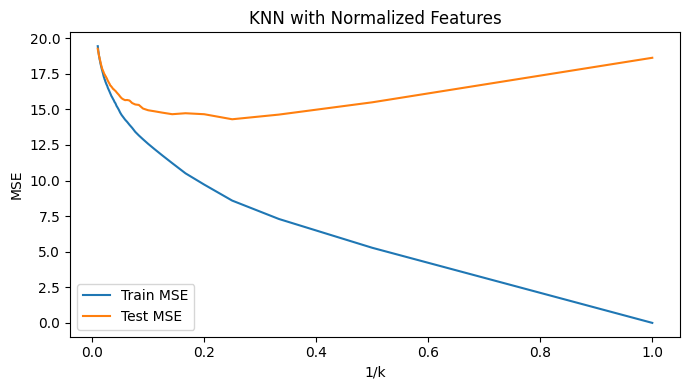

In [18]:
plt.figure(figsize=(7, 4))
plt.plot(1 / normalized_knn["k"], normalized_knn["train_MSE"], label="Train MSE")
plt.plot(1 / normalized_knn["k"], normalized_knn["test_MSE"], label="Test MSE")
plt.xlabel("1/k")
plt.ylabel("MSE")
plt.title("KNN with Normalized Features")
plt.legend()
plt.tight_layout()
plt.show()

### (j) Compare KNN and Linear Regression

In [19]:
comparison = pd.DataFrame([
    ["Linear regression", linear_train_mse, linear_test_mse],
    ["Full second-order regression", full_train_mse, full_test_mse],
    ["Reduced regression", reduced_train_mse, reduced_test_mse],
    ["Raw KNN", best_raw["train_MSE"], best_raw["test_MSE"]],
    ["Normalized KNN", best_normalized["train_MSE"], best_normalized["test_MSE"]]
], columns=["model", "train_MSE", "test_MSE"])

comparison.round(3)


,model,train_MSE,test_MSE
0,Linear regression,20.581,21.240
1,Full second-order regression,17.888,18.647
2,Reduced regression,17.918,18.694
3,Raw KNN,10.601,15.727
4,Normalized KNN,8.591,14.306


The normalized KNN model has the smallest test MSE. Its test MSE is lower than the best regression test MSE, so normalized KNN performs best on this train-test split.

## 2. ISLR: 2.4.1

### (a) The sample size n is extremely large, and the number of predictors p is small.

A flexible method is expected to perform better because the large sample size provides enough information to estimate a flexible fit, while the number of predictors is small.

### (b) The number of predictors p is extremely large, and the number of observations n is small.

A flexible method is expected to perform worse because there are many predictors but few observations, creating a high risk of overfitting.

### (c) The relationship between the predictors and response is highly nonlinear.

A flexible method is expected to perform better because it can follow a strongly nonlinear relationship.

### (d) The variance of the error terms is extremely high.

A flexible method is expected to perform worse because high error variance means there is substantial noise that a flexible method may overfit.

## 3. ISLR: 2.4.7

### (a) Compute the Euclidean distance between each observation and the test point, X1 = X2 = X3 = 0.

In [20]:
observations = np.array([
    [0, 3, 0],
    [2, 0, 0],
    [0, 1, 3],
    [0, 1, 2],
    [-1, 0, 1],
    [1, 1, 1]
])
labels = ["Red", "Red", "Red", "Green", "Green", "Red"]
distances = np.sqrt(np.sum(observations ** 2, axis=1))

distance_table = pd.DataFrame({
    "observation": range(1, 7),
    "X1": observations[:, 0],
    "X2": observations[:, 1],
    "X3": observations[:, 2],
    "distance": distances,
    "class": labels
})
distance_table.round(3)

,observation,X1,X2,X3,distance,class
0,1,0,3,0,3.000,Red
1,2,2,0,0,2.000,Red
2,3,0,1,3,3.162,Red
3,4,0,1,2,2.236,Green
4,5,-1,0,1,1.414,Green
5,6,1,1,1,1.732,Red


### (b) What is our prediction with K = 1? Why?

The closest observation is observation 5, whose class is Green. Therefore, the prediction is **Green**.

### (c) What is our prediction with K = 3? Why?

The three closest observations are 5, 6, and 2. Their classes are Green, Red, and Red, so the majority prediction is **Red**.

### (d) If the Bayes decision boundary is highly nonlinear, should K be large or small? Why?

A small K is expected because it produces a more flexible decision boundary. A large K would smooth the boundary too much.

## References

- UCI Combined Cycle Power Plant Data Set
- *An Introduction to Statistical Learning*, Chapter 2
- Scikit-learn documentation for KNN, preprocessing, and polynomial features